In [ ]:
import pandas as pd
from art_tts.paths import DATA_DIR
from pathlib import Path

vc_dir = DATA_DIR / "VoxCommunis"
utmos_dir = vc_dir / "UTMOS_data"

from art_tts.configs.params_msml1h import lang_codes

# UTMOS

In [2]:
utmos_dir = vc_dir / "UTMOS_data"

def get_vc_utmos_summary(split, version, epochs, sparc=True, generator_version="sparc_multi"):
    if sparc:
        #sparc
        utmos_fp = utmos_dir / f"decoder_files_sparc/{split}/{generator_version}" / "utmos.csv"
        df = pd.read_csv(utmos_fp, names=["id", "sparc"])
        df["lang"] = df["id"].apply(lambda x: x.split("_")[2])
        summary_df = df.copy()
    else:
        summary_df = None
    #v6
    for epoch in epochs:
        ckpt_name = f"grad_{epoch}"
        utmos_fp = utmos_dir / f"decoder_files_{version}/{split}/{ckpt_name}/{generator_version}" / "utmos.csv"

        col = f"{version}_{ckpt_name}"
        df = pd.read_csv(utmos_fp, names=["id", col])
        df["id"] = df["id"].apply(lambda x: x.replace("_decoder", ""))
        if summary_df is None:
            summary_df = df
        else:
            summary_df = summary_df.merge(df, on="id")
        #df["lang"] = df["id"].apply(lambda x: x.split("_")[2])
        #df.groupby("lang").agg({"utmos": ["mean", "std", "count"]})
    return summary_df

## v6

In [10]:
split = "test-20h"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000, 4000, 5000]
summary_df = get_vc_utmos_summary(split, version, epochs, sparc=True)
summary_df.groupby("lang").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])

,sparc,v6_grad_200,v6_grad_500,v6_grad_1000,v6_grad_2000,v6_grad_3000,v6_grad_4000,v6_grad_5000
lang,,,,,,,,
it,2.538623,2.262581,2.361615,2.406797,2.428872,2.400187,2.429281,2.352388
sw,2.327806,2.132409,2.216644,2.273725,2.291061,2.269385,2.294846,2.234100
zh-CN,2.406435,2.045304,2.126144,2.193543,2.191061,2.191433,2.200462,2.125420


In [29]:
split = "dev-1h"
version = "v6"
epochs = [500, 1000, 2000, 3000, 4000, 5000]
it_summary_df = get_vc_utmos_summary(split, version, epochs, sparc=True)
it_summary_df = it_summary_df.groupby("lang").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])

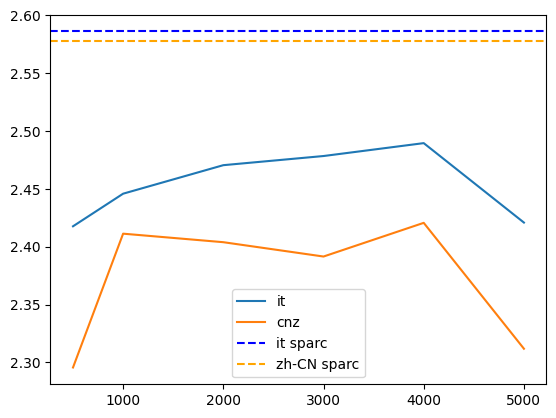

In [31]:
import matplotlib.pyplot as plt
plt.plot(epochs, it_summary_df.loc["it", [f"{version}_grad_{e}" for e in epochs]], label="it")
plt.plot(epochs, it_summary_df.loc["zh-CN", [f"{version}_grad_{e}" for e in epochs]], label="cnz")
plt.axhline(it_summary_df.loc["it", "sparc"], color="blue", linestyle="dashed", label="it sparc")
plt.axhline(it_summary_df.loc["zh-CN", "sparc"], color="orange", linestyle="dashed", label="zh-CN sparc")
plt.legend()

In [20]:
it_summary_df

,sparc,v6_grad_500,v6_grad_1000,v6_grad_2000,v6_grad_3000,v6_grad_4000,v6_grad_5000
lang,,,,,,,
it,2.586055,2.417646,2.445828,2.470474,2.478387,2.489534,2.420858
zh-CN,2.577780,2.295591,2.411259,2.403896,2.391502,2.420626,2.311795


When listening italian sounds italian chinese not very chinese for v6 and sw ok

## v6_zhCN

In [21]:
split = "test-20h"
version = "v6_zhCN"
epochs = [1000, 2000, 3000, 4000, 5000]
summary_df = get_vc_utmos_summary(split, version, epochs, sparc=True)
summary_df.groupby("lang").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])

,sparc,v6_zhCN_grad_1000,v6_zhCN_grad_2000,v6_zhCN_grad_3000,v6_zhCN_grad_4000,v6_zhCN_grad_5000
lang,,,,,,
it,2.538623,2.116334,2.135932,2.143549,2.113514,2.065747
sw,2.327806,2.043563,2.043613,2.043563,2.028757,1.963303
zh-CN,2.406435,2.291204,2.292911,2.295652,2.259353,2.227807


In [35]:
split = "dev-1h"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000, 4000, 5000]
cn_summary_df = get_vc_utmos_summary(split, version, epochs, sparc=True)
cn_summary_df = cn_summary_df.groupby("lang").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])

In [45]:
cn_summary_df

,sparc,v6_zhCN_grad_500,v6_zhCN_grad_1000,v6_zhCN_grad_2000,v6_zhCN_grad_3000,v6_zhCN_grad_4000,v6_zhCN_grad_5000
lang,,,,,,,
it,2.586055,2.231953,2.193827,2.181902,2.197134,2.166817,2.108609
zh-CN,2.577780,2.493274,2.466704,2.443325,2.474537,2.466960,2.430223


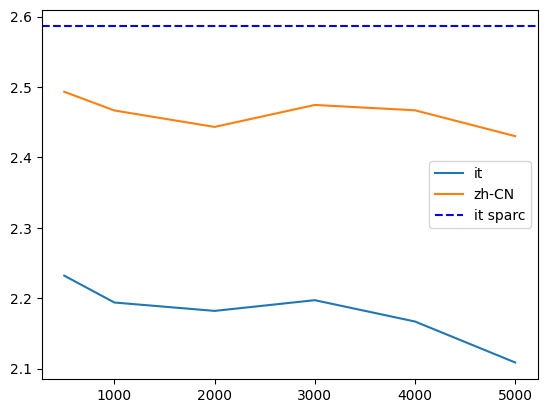

In [36]:
import matplotlib.pyplot as plt
plt.plot(epochs, cn_summary_df.loc["it", [f"{version}_grad_{e}" for e in epochs]], label="it")
plt.plot(epochs, cn_summary_df.loc["zh-CN", [f"{version}_grad_{e}" for e in epochs]], label="zh-CN")
plt.axhline(cn_summary_df.loc["it", "sparc"], color="blue", linestyle="dashed", label="it sparc")
plt.legend()

Better scores for chinese but still very low, UTMOS probably doesn't mean much for non english audio

## msml1h

In [38]:
split = "dev-1h"
version = "msml1h"
epochs = [1000, 2000]
summary_df = get_vc_utmos_summary(split, version, epochs, sparc=True)
summary_df = summary_df.groupby("lang").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
summary_df = summary_df.reset_index(level=0)
summary_df

,lang,sparc,msml1h_grad_1000,msml1h_grad_2000
0,ba,2.706678,2.521148,2.567881
1,be,2.778133,2.615770,2.623062
2,bg,2.778733,2.737800,2.727227
3,bn,2.634316,2.389688,2.467481
4,ca,2.704930,2.389996,2.464349
5,ckb,2.903852,2.724979,2.778612
6,cs,2.965305,2.822793,2.868765
7,cv,3.048328,2.854497,2.907647
8,dv,2.464986,2.278905,2.313927
9,el,2.975305,2.739648,2.742538


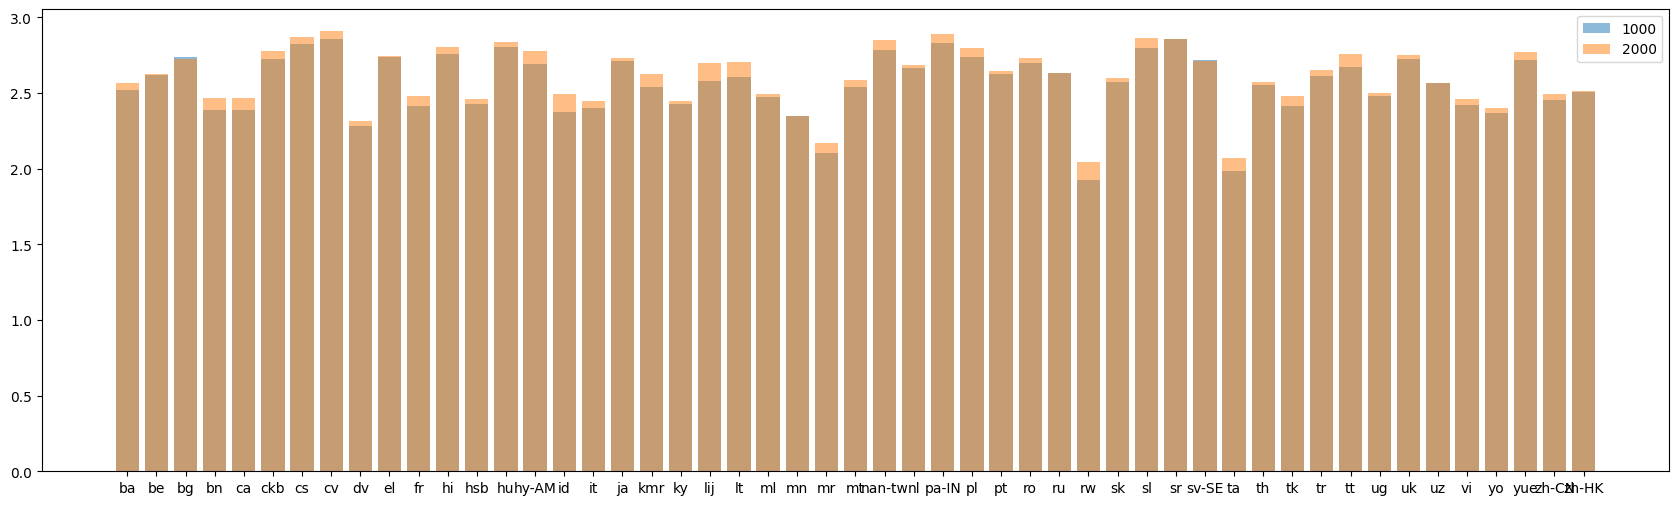

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(21,6))
#plt.bar(summary_df["lang"], summary_df["sparc"], label="sparc", alpha=0.5)
plt.bar(summary_df["lang"], summary_df["msml1h_grad_1000"], label="1000", alpha=0.5)
plt.bar(summary_df["lang"], summary_df["msml1h_grad_2000"], label="2000", alpha=0.5)
plt.legend()
plt.title("Multilingual model UTMOS scores on dev-1h set")

plt.show()
plt.tight_layout()

In [43]:
summary_df["msml1h_grad_2000"].mean()

np.float64(2.6049255595616496)

Better scores for chinese but still very low, UTMOS probably doesn't mean much for non english audio

In [55]:
cn_summary_df.loc["zh-CN"]

sparc                2.577780
v6_zhCN_grad_500     2.493274
v6_zhCN_grad_1000    2.466704
v6_zhCN_grad_2000    2.443325
v6_zhCN_grad_3000    2.474537
v6_zhCN_grad_4000    2.466960
v6_zhCN_grad_5000    2.430223
Name: zh-CN, dtype: float64

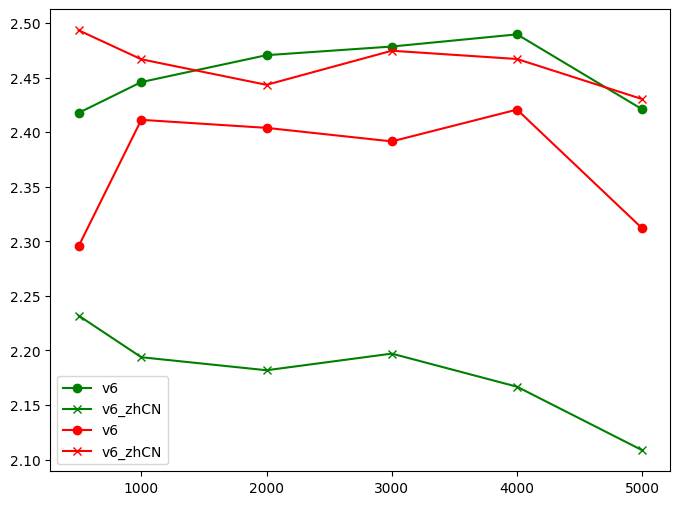

In [62]:
mlms_summary_df = summary_df[summary_df["lang"].isin(['zh-CN', 'it'])]

monoepochs = [500, 1000, 2000, 3000, 4000, 5000]

plt.figure(figsize=(8,6))
monocols = [f"v6_grad_{e}" for e in monoepochs]
plt.plot(monoepochs, it_summary_df.loc["it"][monocols], c="g", label="v6", marker='o')
monocols = [f"v6_zhCN_grad_{e}" for e in monoepochs]
plt.plot(monoepochs, cn_summary_df.loc["it"][monocols], c="g", label="v6_zhCN", marker='x')

monocols = [f"v6_grad_{e}" for e in monoepochs]
plt.plot(monoepochs, it_summary_df.loc["zh-CN"][monocols], c="r", label="v6", marker='o')
monocols = [f"v6_zhCN_grad_{e}" for e in monoepochs]
plt.plot(monoepochs, cn_summary_df.loc["zh-CN"][monocols], c="r", label="v6_zhCN", marker='x')
plt.legend()

# Compare v6 EMA vs SPARC EMA

In [48]:
import pandas as pd
from paths import DATA_DIR
from pathlib import Path

vc_dir = DATA_DIR / "VoxCommunis"

In [49]:
def get_pcc_sparc_analysis(split, version, epochs):
    summary_df = None
    for epoch in epochs:
        gradname = f"grad_{epoch}"
        analysis_fp = vc_dir / split / "analysis" / f"quanti_art_comp_{version}_{gradname}.csv"
        df = pd.read_csv(analysis_fp)
        df["lang"] = df["sample_id"].apply(lambda x: x.split("_")[2])
        df = df.groupby("lang").mean(["pcc_ema", "pcc_pitch", "pcc_loudness"])
        df["version"] = version
        df["epoch"] = epoch
        df.reset_index(inplace=True)
        if summary_df is None:
            summary_df = df
        else:
            summary_df = pd.concat([summary_df, df], axis=0)
    summary_df = summary_df[["lang", "version", "epoch", "pcc_ema", "pcc_pitch", "pcc_loudness"]]
    summary_df.sort_values(by=["lang", "version", "epoch"], inplace=True)
    return summary_df

## v6

In [51]:
split = "test-20h"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000, 4000, 5000]

summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,it,v6,200,0.774598,0.383726,0.768860
0,it,v6,500,0.778463,0.381220,0.779223
0,it,v6,1000,0.782425,0.366670,0.779874
0,it,v6,2000,0.781995,0.356569,0.789193
0,it,v6,3000,0.780127,0.366173,0.788512
0,it,v6,4000,0.780837,0.373111,0.786892
0,it,v6,5000,0.774599,0.347330,0.780842
1,sw,v6,200,0.693255,0.307564,0.685187
1,sw,v6,500,0.694900,0.298243,0.699609
1,sw,v6,1000,0.699152,0.288376,0.704686


In [53]:
split = "dev-1h"
version = "v6"
epochs = [500, 1000, 2000, 3000, 4000, 5000]

summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,fr,v6,500,0.656817,0.354879,0.732271
0,fr,v6,1000,0.650837,0.337746,0.731931
0,fr,v6,2000,0.652984,0.335179,0.738280
0,fr,v6,3000,0.649976,0.374433,0.740621
0,fr,v6,4000,0.652476,0.339071,0.742497
0,fr,v6,5000,0.643607,0.306762,0.731424
1,it,v6,500,0.777395,0.404342,0.789944
1,it,v6,1000,0.783284,0.397354,0.791793
1,it,v6,2000,0.782267,0.390770,0.793805
1,it,v6,3000,0.778816,0.408928,0.799225


## v6_zhCN

In [56]:
split = "test-20h"
version = "v6_zhCN"
epochs = [1000, 2000, 3000, 4000, 5000]
summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,it,v6_zhCN,1000,0.671686,0.316464,0.700386
0,it,v6_zhCN,2000,0.670172,0.310934,0.700933
0,it,v6_zhCN,3000,0.663835,0.311851,0.698444
0,it,v6_zhCN,4000,0.667226,0.294408,0.704065
0,it,v6_zhCN,5000,0.665106,0.318249,0.697111
1,sw,v6_zhCN,1000,0.670975,0.301290,0.670246
1,sw,v6_zhCN,2000,0.668791,0.294922,0.666417
1,sw,v6_zhCN,3000,0.664734,0.290935,0.664541
1,sw,v6_zhCN,4000,0.668479,0.282452,0.668219
1,sw,v6_zhCN,5000,0.666577,0.296775,0.665217


In [57]:
split = "dev-1h"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000, 4000, 5000]

summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,fr,v6_zhCN,500,0.618157,0.278636,0.694083
0,fr,v6_zhCN,1000,0.621400,0.275890,0.696524
0,fr,v6_zhCN,2000,0.620650,0.294999,0.696400
0,fr,v6_zhCN,3000,0.607208,0.277803,0.687278
0,fr,v6_zhCN,4000,0.611074,0.278990,0.693098
0,fr,v6_zhCN,5000,0.611982,0.264356,0.690041
1,it,v6_zhCN,500,0.672682,0.306025,0.713678
1,it,v6_zhCN,1000,0.673881,0.302506,0.713231
1,it,v6_zhCN,2000,0.677679,0.313484,0.711736
1,it,v6_zhCN,3000,0.668810,0.313776,0.711881


## msml1h

In [67]:
split = "dev-1h"
version = "msml1h"
epochs = [1000, 2000, 3000,4000]
summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,ba,msml1h,1000,0.731026,0.343557,0.822689
0,ba,msml1h,2000,0.726766,0.339528,0.822023
0,ba,msml1h,3000,0.724573,0.367931,0.835025
0,ba,msml1h,4000,0.723840,0.341890,0.833339
1,be,msml1h,1000,0.778176,0.381797,0.783228
...,...,...,...,...,...,...
49,zh-CN,msml1h,4000,0.729684,0.300588,0.736769
50,zh-HK,msml1h,1000,0.777340,0.373864,0.772083
50,zh-HK,msml1h,2000,0.774402,0.368420,0.768798
50,zh-HK,msml1h,3000,0.770979,0.365763,0.782833


Epoch 1000 mean pcc_ema 0.737 pcc_pitch 0.385,pcc_loudness, 0.771
Epoch 2000 mean pcc_ema 0.732 pcc_pitch 0.386,pcc_loudness, 0.773
Epoch 3000 mean pcc_ema 0.728 pcc_pitch 0.392,pcc_loudness, 0.780
Epoch 4000 mean pcc_ema 0.729 pcc_pitch 0.386,pcc_loudness, 0.774


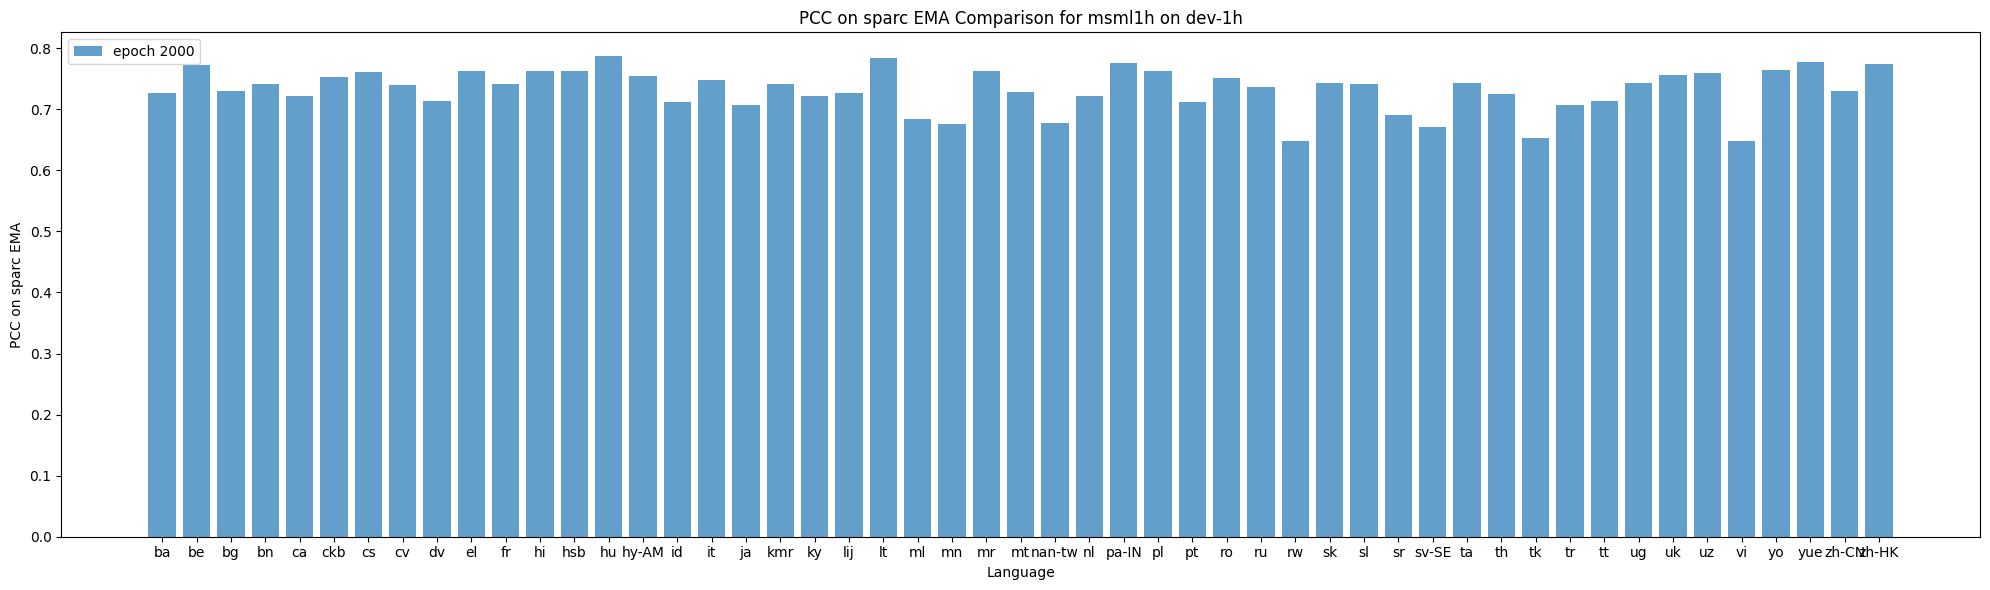

In [68]:
import matplotlib.pyplot as plt

df_1000 = summary_df[summary_df["epoch"]==1000]
df_2000 = summary_df[summary_df["epoch"]==2000]
df_3000 = summary_df[summary_df["epoch"]==3000]
df_4000 = summary_df[summary_df["epoch"]==4000]
df_1000 = df_1000.sort_values(by="pcc_ema", ascending=False)
# show only first 2 decimals in print

print("Epoch 1000 mean pcc_ema", f"{df_1000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_1000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_1000["pcc_loudness"].mean():.3f}")
print("Epoch 2000 mean pcc_ema", f"{df_2000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_2000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_2000["pcc_loudness"].mean():.3f}")
print("Epoch 3000 mean pcc_ema", f"{df_3000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_3000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_3000["pcc_loudness"].mean():.3f}")
print("Epoch 4000 mean pcc_ema", f"{df_4000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_4000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_4000["pcc_loudness"].mean():.3f}")
plt.figure(figsize=(20,6))
#plt.bar(df_1000["lang"], df_1000["pcc_ema"], label="epoch 1000")
plt.bar(df_2000["lang"], df_2000["pcc_ema"], label="epoch 2000", alpha=0.7)
#plt.bar(df_3000["lang"], df_3000["pcc_ema"], label="epoch 3000", alpha=0.4)
plt.xlabel("Language")
plt.ylabel("PCC on sparc EMA")
plt.title(f"PCC on sparc EMA Comparison for {version} on {split}")
plt.legend()
plt.tight_layout()

# msml1h zero-shot

In [62]:
split = "test-1h"
version = "msml1h"
epochs = [1000, 2000, 3000,4000]
summary_df = get_pcc_sparc_analysis(split, version, epochs)
summary_df

,lang,version,epoch,pcc_ema,pcc_pitch,pcc_loudness
0,ab,msml1h,1000,0.620214,0.317378,0.629128
0,ab,msml1h,2000,0.621535,0.360038,0.631664
0,ab,msml1h,3000,0.610901,0.329925,0.639128
0,ab,msml1h,4000,0.612603,0.344927,0.622616
1,eu,msml1h,1000,0.724042,0.335827,0.769231
1,eu,msml1h,2000,0.711708,0.343429,0.762761
1,eu,msml1h,3000,0.705692,0.370429,0.769682
1,eu,msml1h,4000,0.705663,0.348549,0.765668
2,gn,msml1h,1000,0.688677,0.356170,0.768920
2,gn,msml1h,2000,0.677071,0.359650,0.761995


Epoch 1000 mean pcc_ema 0.686 pcc_pitch 0.335,pcc_loudness, 0.721
Epoch 2000 mean pcc_ema 0.681 pcc_pitch 0.350,pcc_loudness, 0.718
Epoch 3000 mean pcc_ema 0.672 pcc_pitch 0.355,pcc_loudness, 0.727
Epoch 4000 mean pcc_ema 0.674 pcc_pitch 0.340,pcc_loudness, 0.720


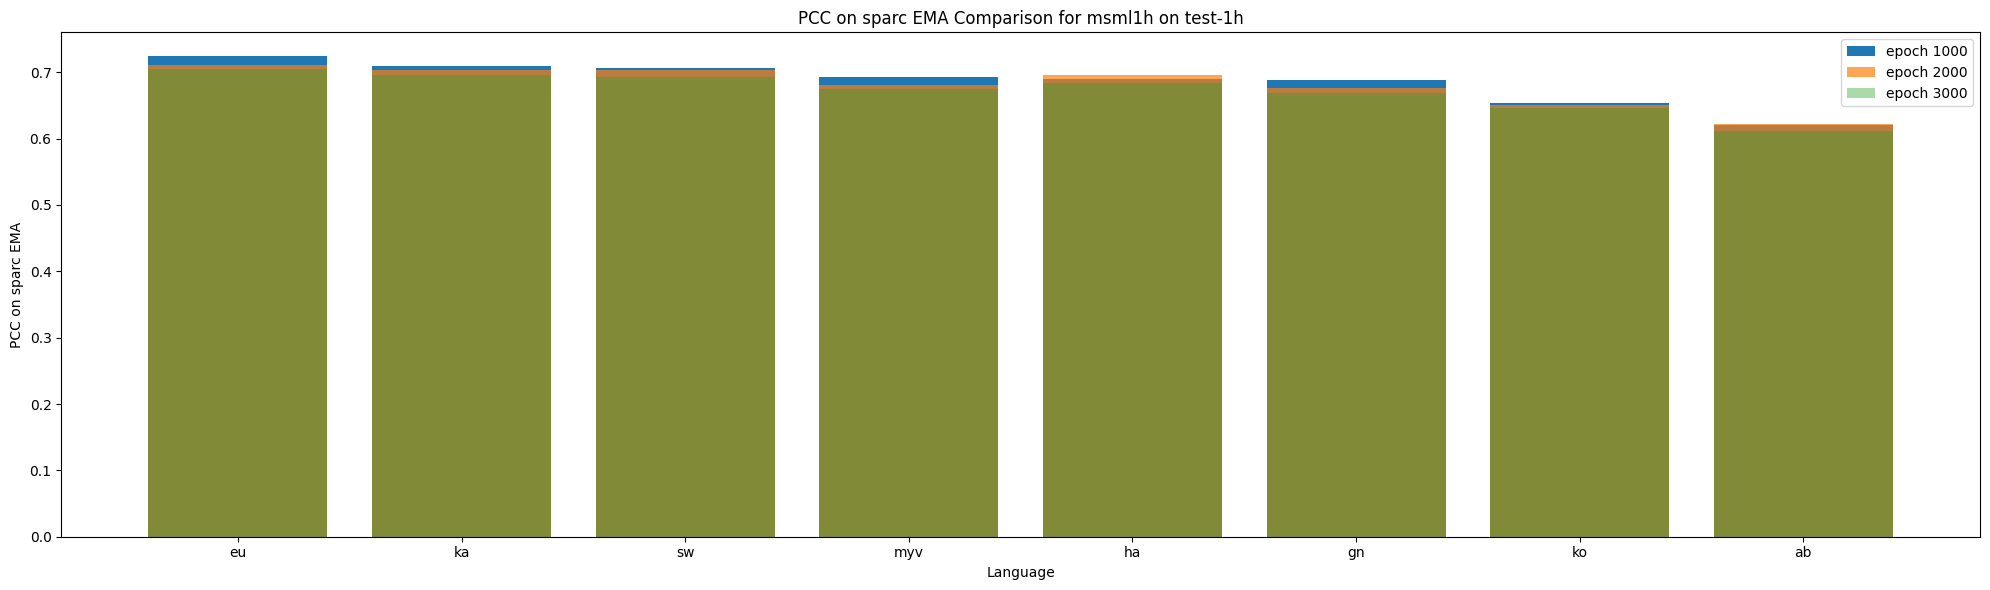

In [65]:
import matplotlib.pyplot as plt

df_1000 = summary_df[summary_df["epoch"]==1000]
df_2000 = summary_df[summary_df["epoch"]==2000]
df_3000 = summary_df[summary_df["epoch"]==3000]
df_4000 = summary_df[summary_df["epoch"]==4000]
df_1000 = df_1000.sort_values(by="pcc_ema", ascending=False)
# show only first 2 decimals in print

print("Epoch 1000 mean pcc_ema", f"{df_1000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_1000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_1000["pcc_loudness"].mean():.3f}")
print("Epoch 2000 mean pcc_ema", f"{df_2000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_2000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_2000["pcc_loudness"].mean():.3f}")
print("Epoch 3000 mean pcc_ema", f"{df_3000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_3000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_3000["pcc_loudness"].mean():.3f}")
print("Epoch 4000 mean pcc_ema", f"{df_4000["pcc_ema"].mean():.3f}", \
      f"pcc_pitch {df_4000["pcc_pitch"].mean():.3f},"  \
      f"pcc_loudness, {df_4000["pcc_loudness"].mean():.3f}")
plt.figure(figsize=(20,6))
plt.bar(df_1000["lang"], df_1000["pcc_ema"], label="epoch 1000")
plt.bar(df_2000["lang"], df_2000["pcc_ema"], label="epoch 2000", alpha=0.7)
plt.bar(df_3000["lang"], df_3000["pcc_ema"], label="epoch 3000", alpha=0.4)
plt.xlabel("Language")
plt.ylabel("PCC on sparc EMA")
plt.title(f"PCC on sparc EMA Comparison for {version} on {split}")
plt.legend()
plt.tight_layout()

In [52]:
# Compare with scores on train languages dev-1h
split = "dev-1h"
version = "msml1h"
epochs = [1000, 2000, 3000, 4000]
train_lang_df = get_pcc_sparc_analysis(split, version, epochs)

split = "test-1h"
zeroshot_lang_df = get_pcc_sparc_analysis(split, version, epochs)

print(zeroshot_lang_df.groupby("epoch").mean("pcc_ema", "pcc_pitch", "pcc_loudness"))
print(train_lang_df.groupby("epoch").mean("pcc_ema", "pcc_pitch", "pcc_loudness"))

        pcc_ema  pcc_pitch  pcc_loudness
epoch                                   
1000   0.685529   0.335180      0.721480
2000   0.680654   0.350062      0.717838
3000   0.672475   0.354881      0.727276
4000   0.674414   0.340090      0.719890
        pcc_ema  pcc_pitch  pcc_loudness
epoch                                   
1000   0.736696   0.384540      0.771118
2000   0.732257   0.385727      0.772913
3000   0.728052   0.392168      0.780414
4000   0.731164   0.381165      0.775535


# Custom datasets

## UTMOS

In [69]:
def get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version=""):
    if sparc:
        #sparc
        utmos_fp = vc_dir / split / "UTMOS_data/decoder_files_sparc" / "utmos.csv"

        df = pd.read_csv(utmos_fp, names=["id", "sparc"])
        df["spk"] = df["id"].apply(lambda x: x.split("_")[spk_parse_idx])
        summary_df = df.copy()
    else:
        summary_df = None
    #v6
    for epoch in epochs:
        ckpt_name = f"grad_{epoch}"
        utmos_fp = vc_dir / split / f"UTMOS_data/decoder_files_{version}/{ckpt_name}/{generator_version}" / "utmos.csv"

        col = f"{version}_{ckpt_name}"
        df = pd.read_csv(utmos_fp, names=["id", col])
        df["id"] = df["id"].apply(lambda x: x.replace("_decoder", ""))
        if summary_df is None:
            summary_df = df
        else:
            summary_df = summary_df.merge(df, on="id")
        df["spk"] = df["id"].apply(lambda x: x.split("_")[spk_parse_idx])
        #df.groupby("lang").agg({"utmos": ["mean", "std", "count"]})
    return summary_df

### v6

In [71]:
spk_parse_idx = 1
split = "MNGU0"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True)
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,v6_grad_200,v6_grad_500,v6_grad_1000,v6_grad_2000,v6_grad_3000
spk,,,,,,
s1,4.066768,3.131459,3.244852,3.271042,3.314405,3.290503


In [74]:
spk_parse_idx = 0
split = "mocha_timit"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True)
truc = summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)

sparc           3.727203
v6_grad_200     3.031303
v6_grad_500     3.186314
v6_grad_1000    3.251797
v6_grad_2000    3.234087
v6_grad_3000    3.228410
dtype: float64

In [84]:
spk_parse_idx = 0
split = "MSPKA_EMA_ita"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True)
truc =summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)
#truc

sparc           3.263006
v6_grad_200     2.626919
v6_grad_500     2.774033
v6_grad_1000    2.799433
v6_grad_2000    2.805306
v6_grad_3000    2.801670
dtype: float64

In [81]:
spk_parse_idx = 0
split = "pb2007"
version = "v6"
epochs = [200, 500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True)
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,v6_grad_200,v6_grad_500,v6_grad_1000,v6_grad_2000,v6_grad_3000
spk,,,,,,
item,2.972503,2.468794,2.55535,2.582724,2.516126,2.471208


### v6_zhCN

In [83]:
spk_parse_idx = 1
split = "MNGU0"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,v6_zhCN_grad_500,v6_zhCN_grad_1000,v6_zhCN_grad_2000,v6_zhCN_grad_3000
spk,,,,,
s1,4.066768,3.230785,3.236484,3.249453,3.227857


In [86]:
spk_parse_idx = 0
split = "mocha_timit"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
truc = summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)


sparc                3.727203
v6_zhCN_grad_500     3.042235
v6_zhCN_grad_1000    3.037886
v6_zhCN_grad_2000    3.052073
v6_zhCN_grad_3000    3.017796
dtype: float64

In [88]:
spk_parse_idx = 0
split = "MSPKA_EMA_ita"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
truc = summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)

sparc                3.263006
v6_zhCN_grad_500     2.594315
v6_zhCN_grad_1000    2.596489
v6_zhCN_grad_2000    2.544289
v6_zhCN_grad_3000    2.571723
dtype: float64

In [89]:
spk_parse_idx = 0
split = "pb2007"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,v6_zhCN_grad_500,v6_zhCN_grad_1000,v6_zhCN_grad_2000,v6_zhCN_grad_3000
spk,,,,,
item,2.972503,2.572059,2.653483,2.679367,2.705042


### msml1h

In [90]:
spk_parse_idx = 1
split = "MNGU0"
version = "msml1h"
epochs = [500, 1000, 2000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,msml1h_grad_500,msml1h_grad_1000,msml1h_grad_2000
spk,,,,
s1,4.066768,3.410528,3.44155,3.473225


In [91]:
spk_parse_idx = 0
split = "mocha_timit"
version = "msml1h"
epochs = [500, 1000, 2000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
truc = summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)

sparc               3.727203
msml1h_grad_500     3.334629
msml1h_grad_1000    3.316414
msml1h_grad_2000    3.371572
dtype: float64

In [92]:
spk_parse_idx = 0
split = "MSPKA_EMA_ita"
version = "msml1h"
epochs = [500, 1000, 2000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
truc = summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])
truc.mean(axis=0)

sparc               3.263006
msml1h_grad_500     2.819635
msml1h_grad_1000    2.735917
msml1h_grad_2000    2.825569
dtype: float64

In [38]:
spk_parse_idx = 0
split = "pb2007"
version = "msml1h"
epochs = [500, 1000, 2000]
summary_df = get_custom_utmos_summary(split, version, epochs, spk_parse_idx, sparc=True, generator_version="sparc_multi")
summary_df.groupby("spk").mean(["sparc"] + [f"{version}_grad_{e}" for e in epochs])
#summary_df.groupby("spk").mean([f"{version}_grad_{e}" for e in epochs])

,sparc,msml1h_grad_500,msml1h_grad_1000,msml1h_grad_2000
spk,,,,
item,2.972503,2.720761,2.748714,2.759274


## EMA pcc

In [93]:
def get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx):
    summary_df = None
    for epoch in epochs:
        gradname = f"grad_{epoch}"
        analysis_fp = vc_dir / split / "analysis" / f"quanti_gt_art_comp_{version}_{gradname}.csv"
        df = pd.read_csv(analysis_fp)
        df["spk"] = df["sample_id"].apply(lambda x: x.split("_")[spk_parse_idx])
        df = df.groupby("spk").mean(['pcc_gt_dec_ema', 'pcc_gt_sparc_ema',
                                     'pcc_sparc_dec_ema','pcc_sparc_dec_pitch',
                                     'pcc_sparc_dec_loudness'])
        df["version"] = version
        df["epoch"] = epoch
        df.reset_index(inplace=True)
        if summary_df is None:
            summary_df = df
        else:
            summary_df = pd.concat([summary_df, df], axis=0)
    summary_df = summary_df[["spk", "version", "epoch", 'pcc_gt_dec_ema', 'pcc_gt_sparc_ema',
                                     'pcc_sparc_dec_ema','pcc_sparc_dec_pitch',
                                     'pcc_sparc_dec_loudness']]
    summary_df.sort_values(by=["spk", "version", "epoch"], inplace=True)
    return summary_df

### v6

In [112]:
split = "MSPKA_EMA_ita"
version = "v6"
epochs = [ 2000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.drop(1).mean(axis=0)

pcc_gt_dec_ema            0.271989
pcc_gt_sparc_ema          0.768980
pcc_sparc_dec_ema         0.272167
pcc_sparc_dec_pitch       0.218770
pcc_sparc_dec_loudness    0.326327
dtype: float64

In [114]:
split = "MNGU0"
version = "v6"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]
spk_parse_idx = 1
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.355791
pcc_gt_sparc_ema          0.861541
pcc_sparc_dec_ema         0.410505
pcc_sparc_dec_pitch       0.479612
pcc_sparc_dec_loudness    0.539016
dtype: float64

In [115]:
split = "mocha_timit"
version = "v6"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.250509
pcc_gt_sparc_ema          0.728390
pcc_sparc_dec_ema         0.313663
pcc_sparc_dec_pitch       0.372675
pcc_sparc_dec_loudness    0.538745
dtype: float64

In [117]:
split = "pb2007"
version = "v6"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.391776
pcc_gt_sparc_ema          0.572592
pcc_sparc_dec_ema         0.503485
pcc_sparc_dec_pitch       0.255054
pcc_sparc_dec_loudness    0.691651
dtype: float64

### v6_zhCN

In [118]:
split = "MSPKA_EMA_ita"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.drop(1).mean(axis=0)

pcc_gt_dec_ema            0.230649
pcc_gt_sparc_ema          0.768980
pcc_sparc_dec_ema         0.239785
pcc_sparc_dec_pitch       0.352338
pcc_sparc_dec_loudness    0.341305
dtype: float64

In [119]:
split = "MNGU0"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]

spk_parse_idx = 1
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.341360
pcc_gt_sparc_ema          0.861541
pcc_sparc_dec_ema         0.393204
pcc_sparc_dec_pitch       0.545949
pcc_sparc_dec_loudness    0.564639
dtype: float64

In [120]:
split = "mocha_timit"
version = "v6_zhCN"
epochs = [500, 1000, 2000, 3000]
epochs = [ 2000]

spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.238655
pcc_gt_sparc_ema          0.728390
pcc_sparc_dec_ema         0.295035
pcc_sparc_dec_pitch       0.258723
pcc_sparc_dec_loudness    0.556810
dtype: float64

In [121]:
split = "pb2007"
version = "v6_zhCN"
epochs = [500, 1000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.381603
pcc_gt_sparc_ema          0.572592
pcc_sparc_dec_ema         0.485634
pcc_sparc_dec_pitch       0.185876
pcc_sparc_dec_loudness    0.729615
dtype: float64

### msml1h

In [122]:
split = "MSPKA_EMA_ita"
version = "msml1h"
epochs = [500, 1000, 2000, 3000, 4000]
epochs = [ 2000]

spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.drop(1).mean(axis=0)

pcc_gt_dec_ema            0.265624
pcc_gt_sparc_ema          0.768980
pcc_sparc_dec_ema         0.266949
pcc_sparc_dec_pitch       0.310765
pcc_sparc_dec_loudness    0.313312
dtype: float64

In [123]:
split = "MNGU0"
version = "msml1h"
epochs = [500, 1000, 2000, 3000, 4000]
epochs = [ 2000]
spk_parse_idx = 1
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.388119
pcc_gt_sparc_ema          0.861541
pcc_sparc_dec_ema         0.443444
pcc_sparc_dec_pitch       0.544826
pcc_sparc_dec_loudness    0.555584
dtype: float64

In [124]:
split = "mocha_timit"
version = "msml1h"
epochs = [500, 1000, 2000, 3000, 4000]
epochs = [ 2000]
spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.266562
pcc_gt_sparc_ema          0.728390
pcc_sparc_dec_ema         0.334828
pcc_sparc_dec_pitch       0.302798
pcc_sparc_dec_loudness    0.546046
dtype: float64

In [125]:
split = "pb2007"
version = "msml1h"
epochs = [500, 1000, 2000, 3000, 4000]
epochs = [ 2000]

spk_parse_idx = 0
summary_df = get_custom_pcc_sparc_analysis(split, version, epochs, spk_parse_idx)
summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
summary_df.mean(axis=0)

pcc_gt_dec_ema            0.409936
pcc_gt_sparc_ema          0.572592
pcc_sparc_dec_ema         0.512103
pcc_sparc_dec_pitch       0.347235
pcc_sparc_dec_loudness    0.699851
dtype: float64

In [132]:
data = []
for version in ['v6', 'v6_zhCN', 'msml1h']:
    for epoch in [2000]:
        for split, spk_parse_idx in [("MNGU0", 1), ("mocha_timit", 0), ("MSPKA_EMA_ita", 0)]:#, ("pb2007", 0)]:
            print(f"{version} {epoch} {split}")
            summary_df = get_custom_pcc_sparc_analysis(split, version, [epoch], spk_parse_idx)
            summary_df = summary_df[["pcc_gt_dec_ema", "pcc_gt_sparc_ema", "pcc_sparc_dec_ema", "pcc_sparc_dec_pitch", "pcc_sparc_dec_loudness"]]
            #print(summary_df.mean(axis=0))
            row = {"version": version, "dataset": split}
            if split == "MSPKA_EMA_ita":
                row.update(summary_df.drop(1).mean(axis=0).to_dict())
            else:
                row.update(summary_df.mean(axis=0).to_dict())
            data.append(row)
df = pd.DataFrame(data)

v6 2000 MNGU0
v6 2000 mocha_timit
v6 2000 MSPKA_EMA_ita
v6_zhCN 2000 MNGU0
v6_zhCN 2000 mocha_timit
v6_zhCN 2000 MSPKA_EMA_ita
msml1h 2000 MNGU0
msml1h 2000 mocha_timit
msml1h 2000 MSPKA_EMA_ita


In [134]:
df.round(3)

,version,dataset,pcc_gt_dec_ema,pcc_gt_sparc_ema,pcc_sparc_dec_ema,pcc_sparc_dec_pitch,pcc_sparc_dec_loudness
0,v6,MNGU0,0.356,0.862,0.411,0.480,0.539
1,v6,mocha_timit,0.251,0.728,0.314,0.373,0.539
2,v6,MSPKA_EMA_ita,0.272,0.769,0.272,0.219,0.326
3,v6_zhCN,MNGU0,0.341,0.862,0.393,0.546,0.565
4,v6_zhCN,mocha_timit,0.239,0.728,0.295,0.259,0.557
5,v6_zhCN,MSPKA_EMA_ita,0.231,0.769,0.240,0.352,0.341
6,msml1h,MNGU0,0.388,0.862,0.443,0.545,0.556
7,msml1h,mocha_timit,0.267,0.728,0.335,0.303,0.546
8,msml1h,MSPKA_EMA_ita,0.266,0.769,0.267,0.311,0.313


In [135]:
grouped_df = df.groupby(['dataset', 'version']).mean()
grouped_df

pcc_gt_dec_ema  pcc_gt_sparc_ema  pcc_sparc_dec_ema  \
dataset       version                                                        
MNGU0         msml1h         0.388119          0.861541           0.443444   
              v6             0.355791          0.861541           0.410505   
              v6_zhCN        0.341360          0.861541           0.393204   
MSPKA_EMA_ita msml1h         0.265624          0.768980           0.266949   
              v6             0.271989          0.768980           0.272167   
              v6_zhCN        0.230649          0.768980           0.239785   
mocha_timit   msml1h         0.266562          0.728390           0.334828   
              v6             0.250509          0.728390           0.313663   
              v6_zhCN        0.238655          0.728390           0.295035   

                       pcc_sparc_dec_pitch  pcc_sparc_dec_loudness  
dataset       version                                               
MNGU0         msml1h              0.544826                0.555584  
              v6                  0.479612                0.539016  
              v6_zhCN             0.545949                0.564639  
MSPKA_EMA_ita msml1h              0.310765                0.313312  
              v6                  0.218770                0.326327  
              v6_zhCN             0.352338                0.341305  
mocha_timit   msml1h              0.302798                0.546046  
              v6                  0.372675                0.538745  
              v6_zhCN             0.258723                0.556810